In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import xclimate as xclim

In [23]:
grid = xclim.load_fhist_ppe_grid()

rootdir = "/glade/work/bbuchovecky/fhist_ppe_analysis/proc/dist"
time_period = "19850101-20141231"

ndays = 30
doy_30 = xr.open_dataset(f"{rootdir}/TSA_pool_{ndays}d_window/FHIST_TSA_pool_{ndays}d_window_{time_period}_doy.nc").reindex_like(grid, tolerance=1e-3, method="nearest").sel(lat=slice(-58, None))
stats_30 = xr.open_dataset(f"{rootdir}/TSA_pool_{ndays}d_window/FHIST_TSA_pool_{ndays}d_window_{time_period}_stats.nc").reindex_like(grid, tolerance=1e-3, method="nearest").sel(lat=slice(-58, None))
kde_30 = xr.open_dataset(f"{rootdir}/TSA_pool_{ndays}d_window/FHIST_TSA_pool_{ndays}d_window_{time_period}_kde.nc").reindex_like(grid, tolerance=1e-3, method="nearest").sel(lat=slice(-58, None))

ndays = 90
doy_90 = xr.open_dataset(f"{rootdir}/TSA_pool_{ndays}d_window/FHIST_TSA_pool_{ndays}d_window_{time_period}_doy.nc").reindex_like(grid, tolerance=1e-3, method="nearest").sel(lat=slice(-58, None))
stats_90 = xr.open_dataset(f"{rootdir}/TSA_pool_{ndays}d_window/FHIST_TSA_pool_{ndays}d_window_{time_period}_anom_stats.nc").reindex_like(grid, tolerance=1e-3, method="nearest").sel(lat=slice(-58, None))
kde_90 = xr.open_dataset(f"{rootdir}/TSA_pool_{ndays}d_window/FHIST_TSA_pool_{ndays}d_window_{time_period}_anom_kde.nc").reindex_like(grid, tolerance=1e-3, method="nearest").sel(lat=slice(-58, None))

In [6]:
gc = dict(lat=45, lon=270, method="nearest")

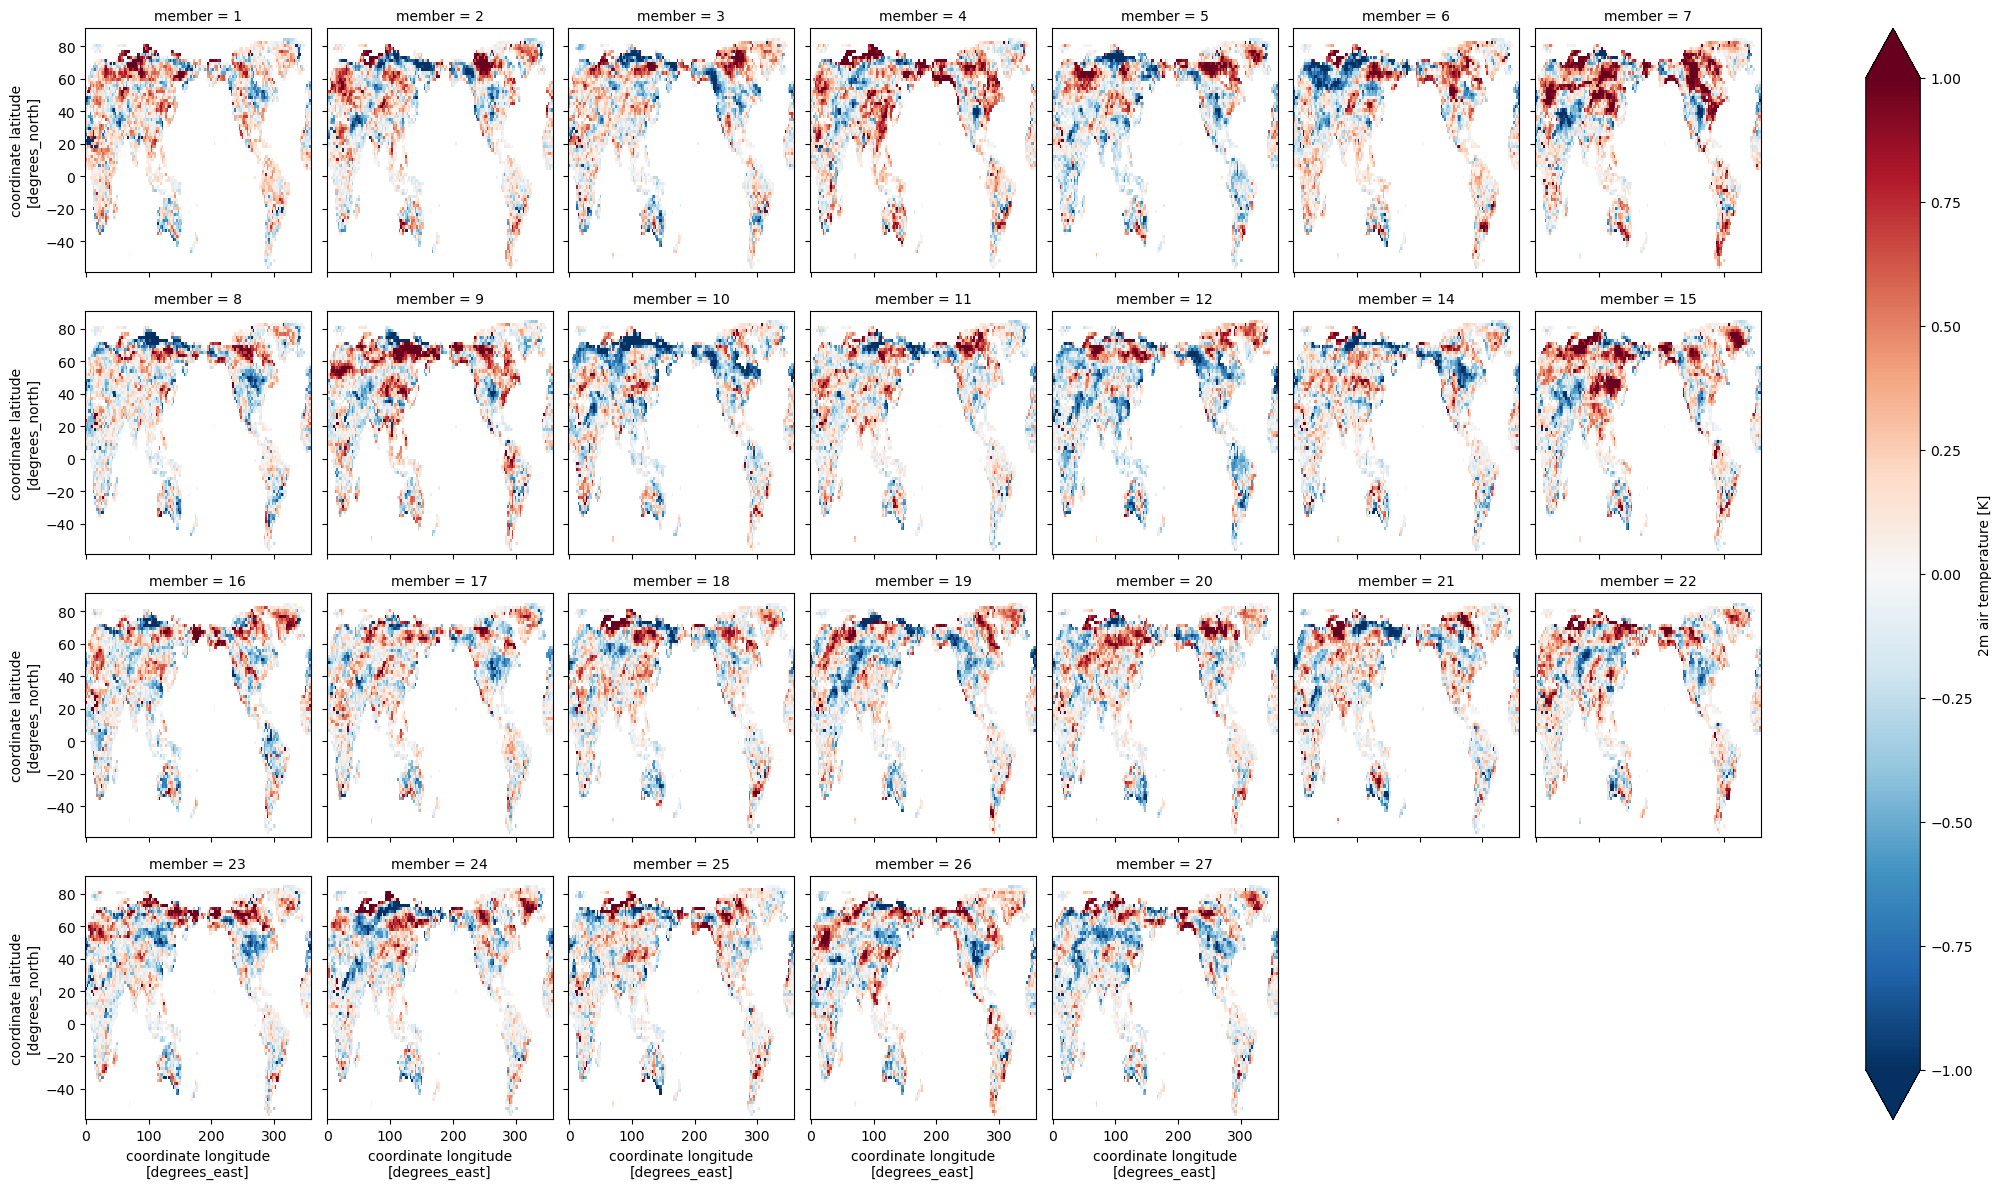

In [30]:
(
    stats_30.quantiles.sel(quantile=0.95, member=slice(1, None))
    - stats_30.quantiles.sel(quantile=0.95, member=0)
).plot(col="member", col_wrap=7, robust=True, vmin=-1, vmax=1, cmap="RdBu_r")

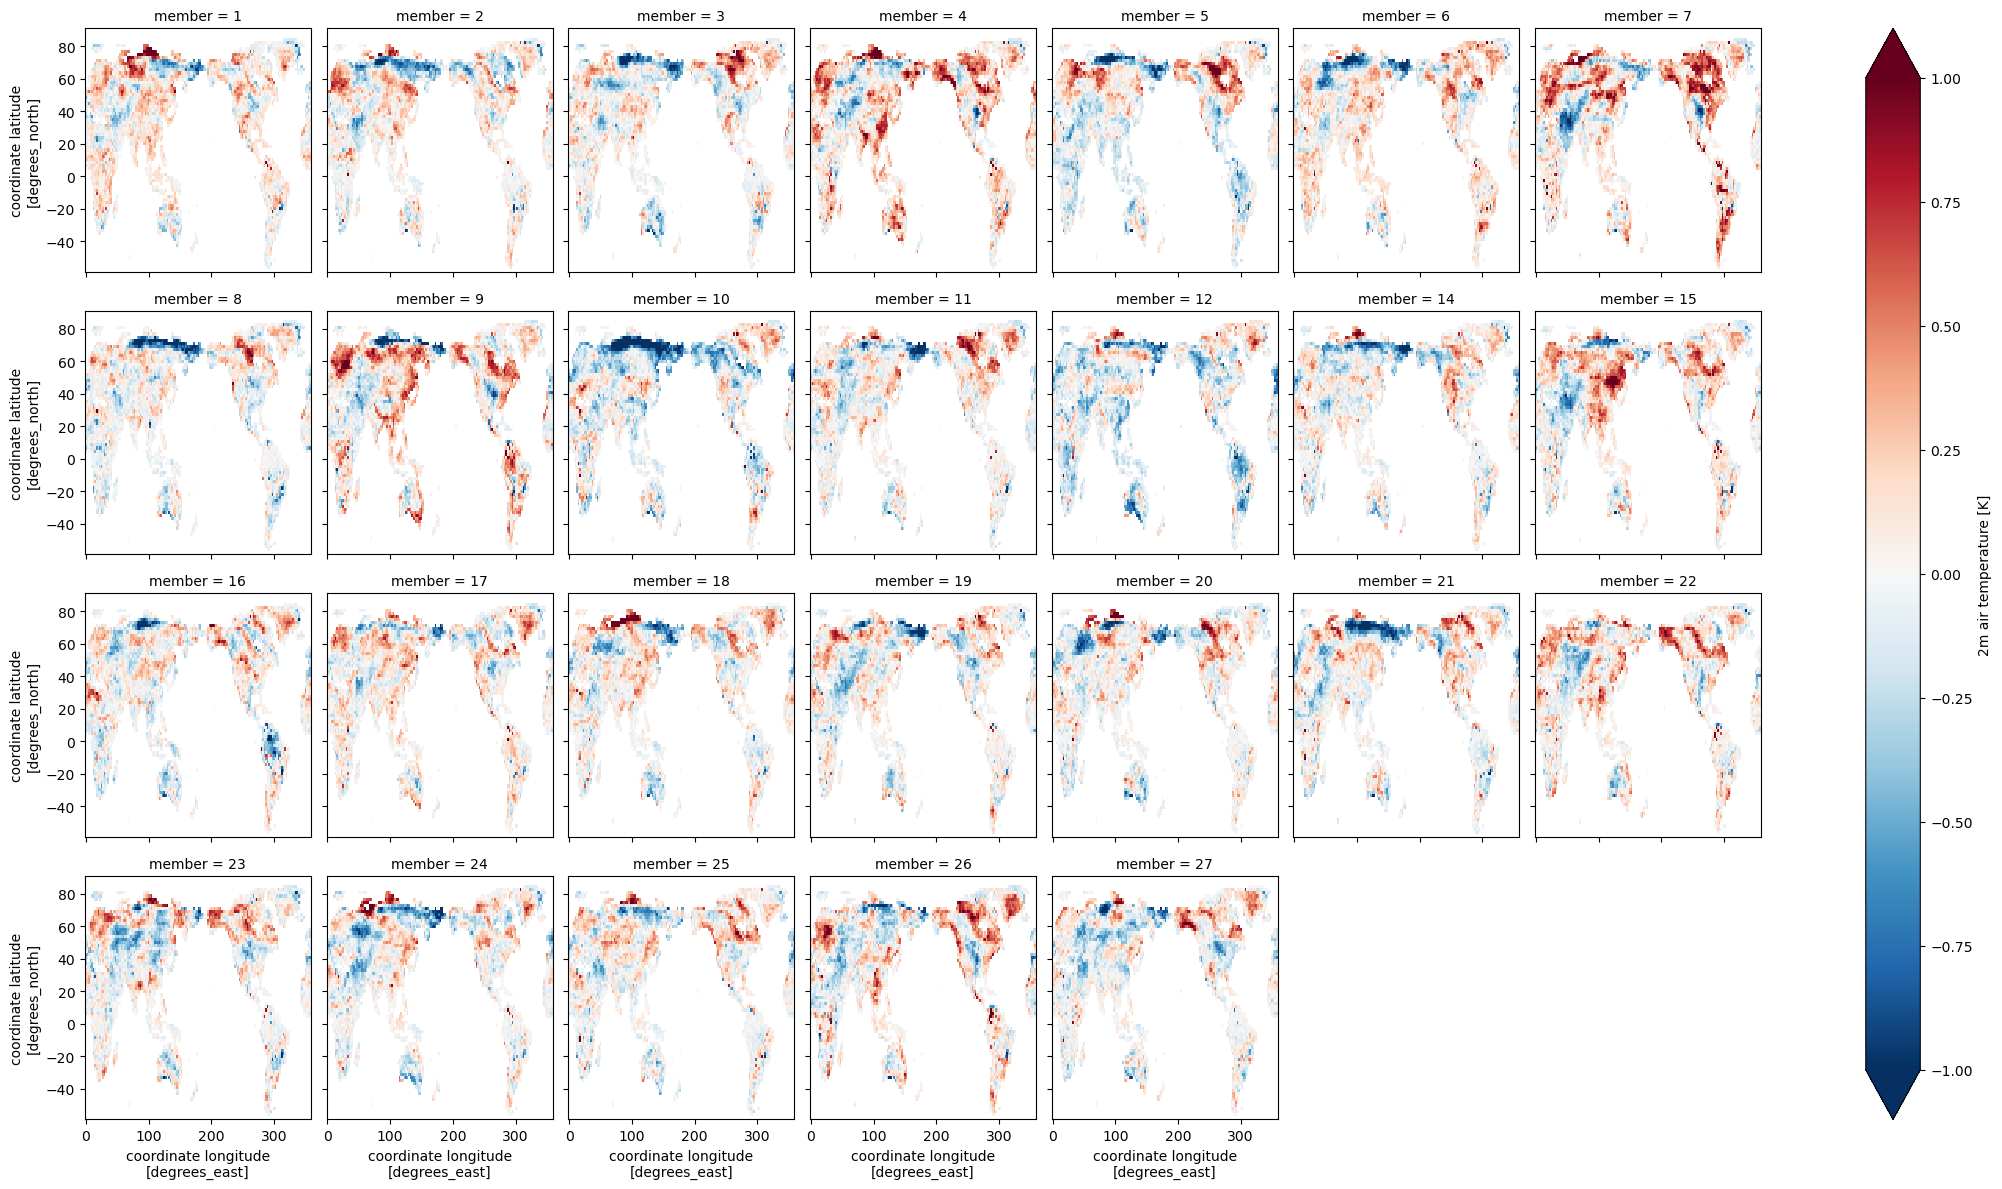

In [29]:
(
    stats_90.quantiles.sel(quantile=0.95, member=slice(1, None))
    - stats_90.quantiles.sel(quantile=0.95, member=0)
).plot(col="member", col_wrap=7, vmin=-1, vmax=1, cmap="RdBu_r")

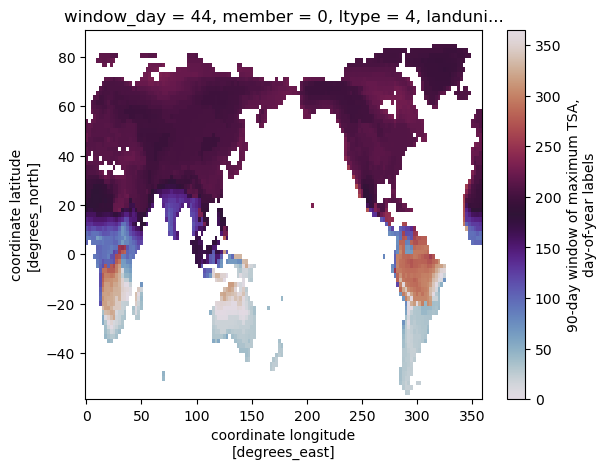

In [38]:
doy_90.max_window_doy.sel(window_day=44, member=0).where(grid.LANDFRAC>0).plot(cmap="twilight", vmin=0, vmax=365)

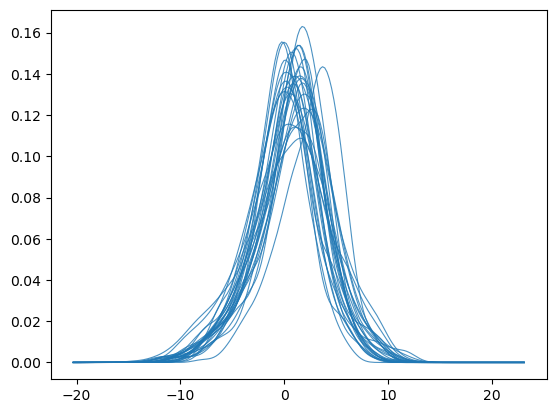

In [14]:
for m in kde.member:
    plt.plot(
        kde.eval_points,
        kde.kde.sel(member=m, **gc),
        c="tab:blue", lw=0.8, alpha=0.8
    )

In [13]:
kde.eval_points

<xarray.DataArray 'eval_points' (points: 200)> Size: 2kB
[200 values with dtype=float64]
Coordinates:
  * points   (points) int64 2kB 0 1 2 3 4 5 6 7 ... 193 194 195 196 197 198 199

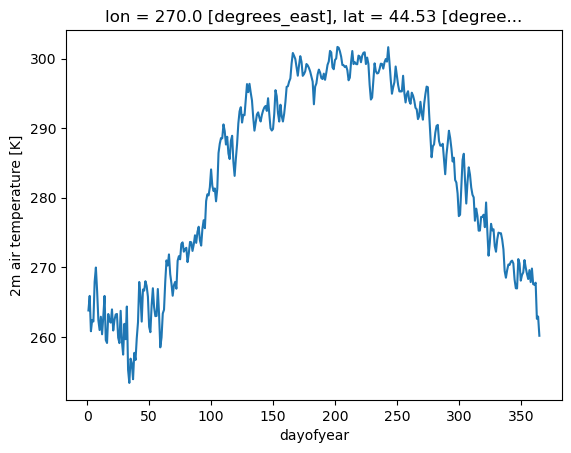

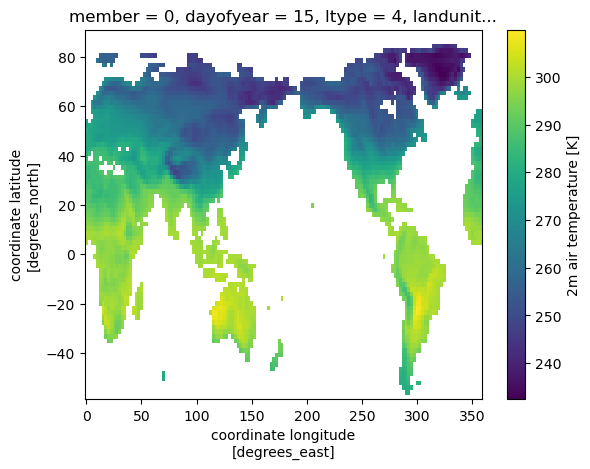

In [15]:
plt.figure()
clim.TSA.sel(member=0, **gc).plot()

plt.figure()
clim.TSA.sel(member=0, dayofyear=15).plot()

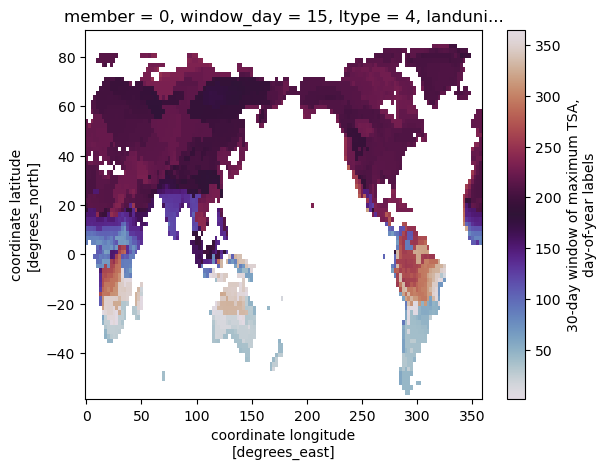

In [34]:
plt.figure()
doy.max_window_doy.sel(member=0, window_day=15).where(grid.LANDAREA > 0).plot(cmap="twilight")

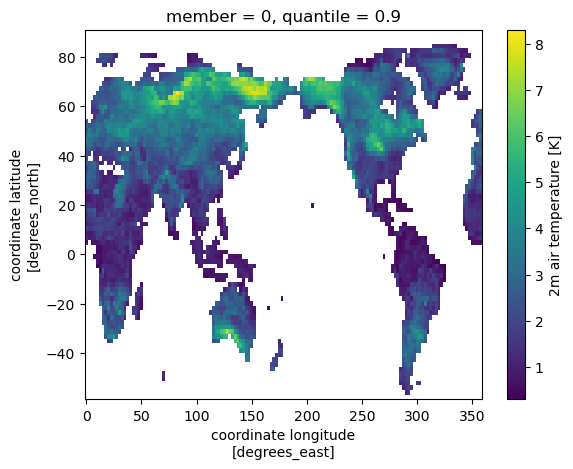

In [36]:
stats.quantiles.sel(member=0, quantile=0.90).plot()

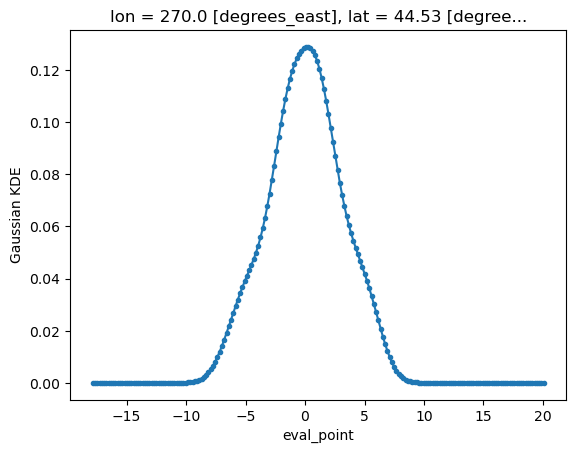

In [37]:
kde.kde.sel(member=0, **gc).plot(marker=".")

In [25]:
doy.max_window_doy.sel(member=0, window_day=15).min()

<xarray.DataArray 'max_window_doy' ()> Size: 8B
array(1)
Coordinates:
    member      int64 8B 0
    window_day  int64 8B 15
Attributes:
    long_name:  30-day window of maximum TSA, day-of-year labels

In [2]:
da = xclim.load_fhist("TREFHT_day_1")

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
n = 27


In [133]:
y = da.TREFHT.sel(member=0, time=slice('1950-01-01', '1951-12-31')).compute()
y_clim = y.groupby('time.dayofyear').mean().compute()
y_anom = (y.groupby("time.dayofyear") - y_clim).compute()

In [134]:
DEFAULT_WINDOW_DAYS = 30


def compute_max_window_doy(x: xr.DataArray, ndays: int = DEFAULT_WINDOW_DAYS) -> xr.DataArray:
    """
    Identify the ndays-day window of the annual cycle with the maximum
    mean, defined as the contiguous run of ndays days ending on the day
    that maximizes the trailing ndays-day rolling mean. Works for any
    ndays (odd or even) since it avoids the ambiguity of a "centered"
    window for even lengths.

    Parameters
    ----------
    x : xr.DataArray
        Climatological daily data with a 'dayofyear' dimension (plus
        arbitrary other dims, e.g. lat, lon, member).
    ndays : int, optional
        Window length in days.

    Returns
    -------
    xr.DataArray
        1-indexed dayofyear labels of the window, dims
        (*x.dims_excluding_dayofyear, 'window_day'), wrap-aware across
        the Dec-Jan boundary. Use with .sel(dayofyear=...) to subset
        other variables sharing the same dayofyear coordinate convention.
    """
    n_doy = x.sizes["dayofyear"]
    if ndays > n_doy:
        raise ValueError(f"ndays ({ndays}) exceeds available days ({n_doy})")

    pad = ndays - 1
    x_padded = xr.concat(
        [x.isel(dayofyear=slice(-pad, None)), x],
        dim="dayofyear",
    )

    trailing_mean = (
        x_padded.rolling(dayofyear=ndays, center=False)
        .mean()
        .isel(dayofyear=slice(pad, None))  # restrict candidates to original year
        .fillna(-np.inf)
    )

    end_iday = trailing_mean.argmax(dim="dayofyear").compute()  # 0-indexed, within original year

    offsets = np.arange(-(ndays - 1), 1)  # e.g. [-29, ..., 0] for ndays=30
    doy_labels = np.mod(end_iday.values[..., None] + offsets, n_doy) + 1  # 1-indexed

    return xr.DataArray(
        doy_labels,
        dims=end_iday.dims + ("window_day",),
        coords={**end_iday.coords, "window_day": np.arange(ndays)},
        name="max_window_doy",
        attrs={"long_name": f"{ndays}-day window of maximum {x.name}, day-of-year labels"},
    )


def select_window(other: xr.DataArray, doy_labels: xr.DataArray) -> xr.DataArray:
    """
    Select time steps of `other` whose day-of-year falls within the
    per-gridpoint window defined by `doy_labels`.

    Parameters
    ----------
    other : xr.DataArray
        Array with a 'time' dimension (plus dims matching doy_labels,
        e.g. lat, lon, member).
    doy_labels : xr.DataArray
        Output of max_window_doy: 1-indexed dayofyear labels, dims
        (*non-time dims, 'window_day').

    Returns
    -------
    xr.DataArray
        `other` masked (NaN outside the window) with the same dims as
        `other`, plus a boolean 'in_window' mask attached for
        transparency if you'd rather use .where() yourself downstream.
    """
    time_doy = other["time"].dt.dayofyear  # dims: (time,)

    # Broadcast comparison: (time,) vs (*, window_day) -> (time, *, window_day)
    mask = (time_doy == doy_labels).any(dim="window_day")  # dims: (time, *doy_labels.dims[:-1])

    return other.where(mask)


def select_window_single_year(other: xr.DataArray, doy_labels: xr.DataArray) -> xr.DataArray:
    """
    Select a single year's worth of `other` at the days-of-year given
    by `doy_labels`, replacing the 'time' dim with 'window_day'.

    Assumes `other`'s time index covers exactly one year, contiguous,
    calendar-matched to doy_labels' dayofyear convention (i.e.,
    position i in `other` along time corresponds to dayofyear i+1,
    with no gaps).
    """
    n_doy = other.sizes["time"]
    idx = (doy_labels - 1).astype(int)  # 0-indexed position == dayofyear - 1

    if int(idx.max()) >= n_doy or int(idx.min()) < 0:
        raise ValueError("doy_labels out of range for other's time length; check calendar match")

    selected = other.isel(time=idx)  # vectorized isel: 'time' dim replaced by idx's dims (*, window_day)
    return selected.assign_coords(window_day=doy_labels.window_day)


def select_window_multi_year(other: xr.DataArray, doy_labels: xr.DataArray) -> xr.DataArray:
    """
    For each year in `other`, select the days-of-year given by
    doy_labels, producing dims (year, window_day, *other_dims_minus_time).

    Assumes each year in `other` has the same calendar convention as
    doy_labels (e.g. both noleap, or both accounting for leap years
    consistently) and that each year is complete (no missing days).
    """
    idx = (doy_labels - 1).astype(int)  # 0-indexed offsets within a single year

    yearly = []
    for yr, year_slice in other.groupby("time.year"):
        n_doy_yr = year_slice.sizes["time"]
        if int(idx.max()) >= n_doy_yr:
            raise ValueError(f"doy_labels exceed year {yr}'s length ({n_doy_yr} days); leap-year mismatch?")
        sel = year_slice.isel(time=idx).assign_coords(window_day=doy_labels.window_day)
        sel = sel.expand_dims(year=[yr])
        yearly.append(sel.drop_vars("time", errors="ignore"))

    return xr.concat(yearly, dim="year")

In [135]:
y_clim_window_max_doy = compute_max_window_doy(y_clim).compute()

In [136]:
y_window_max = select_window_multi_year(y_anom, y_clim_window_max_doy).compute()

In [138]:
gc = dict(lat=45, lon=270, method="nearest")

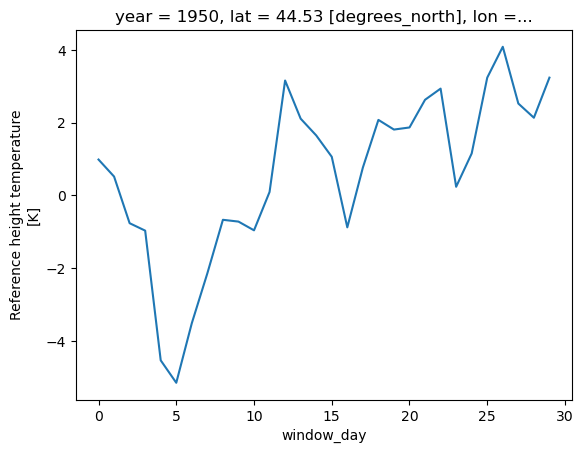

In [139]:
y_window_max.sel(year=1950, **gc).plot()

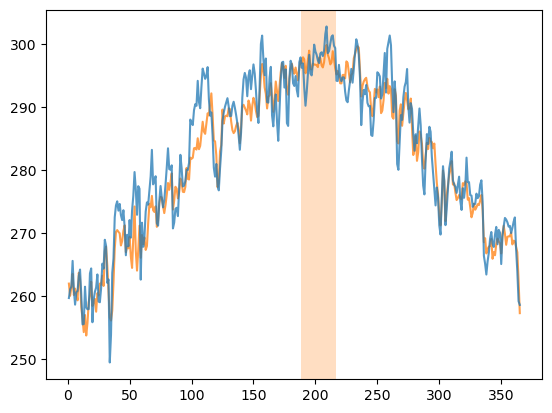

In [ ]:
doy = y.sel(time=slice("1950-01-01", "1950-12-31")).time.dt.dayofyear

y_anom_gc = y_anom.sel(time=slice("1950-01-01", "1950-12-31")).sel(**gc)
y_gc = y.sel(time=slice("1950-01-01", "1950-12-31")).sel(**gc)
y_clim_gc = y_clim.sel(**gc)
y_clim_max_gc = y_clim_window_max_doy.sel(**gc)

plt.plot(doy, y_clim_gc, c='tab:orange', alpha=0.75)
# plt.plot(doy, y_anom_gc)
plt.plot(doy, y_gc, alpha=0.75)
plt.axvspan(
    doy[y_clim_max_gc[0]],
    doy[y_clim_max_gc[-1]],
    facecolor="tab:orange", alpha=0.25,
    label="max 30-day running mean"
)

In [114]:
y_window_max.quantile(0.95)

<xarray.DataArray 'TREFHT' (year: 2, lat: 96, lon: 144, window_day: 30)> Size: 3MB
array([[[[246.11597, 243.47957, 242.34038, ..., 248.71777, 245.29437,
          243.92622],
         [245.98445, 243.36241, 242.21404, ..., 248.58975, 245.1852 ,
          243.81303],
         [245.96017, 243.34088, 242.19151, ..., 248.5652 , 245.16449,
          243.79196],
         ...,
         [246.15962, 243.52037, 242.38112, ..., 248.75998, 245.33409,
          243.96211],
         [246.15642, 243.5175 , 242.37814, ..., 248.75674, 245.33089,
          243.95943],
         [246.14452, 243.50606, 242.36676, ..., 248.74548, 245.32   ,
          243.94972]],

        [[243.06094, 244.12758, 248.33012, ..., 245.20152, 244.02928,
          244.05225],
         [242.8015 , 243.89206, 248.10529, ..., 244.95274, 243.78278,
          243.80875],
         [242.68755, 243.81316, 248.03825, ..., 244.867  , 243.69937,
          243.71515],
...
         [273.392  , 273.3319 , 273.22055, ..., 273.37796, 273.3349 ,
          273.39426],
         [273.39545, 273.33417, 273.20767, ..., 273.37582, 273.3324 ,
          273.40323],
         [273.39865, 273.3358 , 273.19507, ..., 273.3753 , 273.3321 ,
          273.4103 ]],

        [[273.3731 , 273.2322 , 273.20605, ..., 273.3042 , 273.33365,
          273.3157 ],
         [273.37308, 273.23218, 273.20605, ..., 273.30353, 273.33276,
          273.31476],
         [273.37308, 273.23218, 273.20605, ..., 273.30353, 273.33276,
          273.31476],
         ...,
         [273.37308, 273.23218, 273.20602, ..., 273.30426, 273.3337 ,
          273.31577],
         [273.37308, 273.23218, 273.20602, ..., 273.30426, 273.3337 ,
          273.31577],
         [273.37308, 273.23218, 273.20602, ..., 273.30426, 273.3337 ,
          273.31577]]]], shape=(2, 96, 144, 30), dtype=float32)
Coordinates:
  * year        (year) int64 16B 1950 1951
  * lat         (lat) float64 768B -90.0 -88.11 -86.21 ... 86.21 88.11 90.0
  * lon         (lon) float64 1kB 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
  * window_day  (window_day) int64 240B 0 1 2 3 4 5 6 7 ... 23 24 25 26 27 28 29
    member      int64 8B 0
Attributes:
    units:         K
    long_name:     Reference height temperature
    cell_methods:  time: mean

In [116]:
y_window_pooled = y_window_max.stack(pool=["year", "window_day"])

In [119]:
y_window_pooled.quantile([0.90, 0.95, 0.99], dim="pool")

<xarray.DataArray 'TREFHT' (quantile: 3, lat: 96, lon: 144)> Size: 332kB
array([[[249.70281525, 249.57840118, 249.55509949, ..., 249.74416504,
         249.74109497, 249.72973938],
        [250.73961792, 250.44041748, 250.13081512, ..., 251.16007385,
         251.02076111, 250.88788147],
        [250.01197052, 249.70922546, 249.5166214 , ..., 251.38774109,
         251.10825195, 250.50624542],
        ...,
        [273.52162781, 273.52032776, 273.53252258, ..., 273.47653198,
         273.48726807, 273.51080017],
        [273.43404236, 273.43040466, 273.43400269, ..., 273.41650391,
         273.41705933, 273.42929382],
        [273.38439331, 273.38464661, 273.38464661, ..., 273.38439026,
         273.38439026, 273.38439026]],

       [[251.30106964, 251.1668602 , 251.14156113, ..., 251.34580383,
         251.3424614 , 251.33014679],
        [251.70875397, 251.47921753, 251.41223984, ..., 251.99790802,
         251.94078827, 251.81278992],
        [251.01399841, 250.84033508, 250.74339752, ..., 251.76013107,
         251.42052689, 251.31492767],
...
        [273.55639496, 273.58842468, 273.60998688, ..., 273.50761871,
         273.51563721, 273.53015137],
        [273.47105865, 273.4822876 , 273.48888702, ..., 273.4453186 ,
         273.44224396, 273.45571442],
        [273.41030731, 273.41045837, 273.41045837, ..., 273.41026459,
         273.41026459, 273.41026306]],

       [[252.61811707, 252.48685913, 252.46272385, ..., 252.66359528,
         252.66063126, 252.64834732],
        [252.71698944, 252.45281937, 252.34311401, ..., 252.67204697,
         252.91306076, 252.85114304],
        [251.63655289, 251.27263885, 251.06875702, ..., 252.58379608,
         252.45191803, 252.17632339],
        ...,
        [273.61512939, 273.61075653, 273.6319043 , ..., 273.63804779,
         273.62838837, 273.62154572],
        [273.52895325, 273.52983887, 273.53456635, ..., 273.51949158,
         273.52125092, 273.52409912],
        [273.45510773, 273.45534393, 273.45536743, ..., 273.45511322,
         273.45513123, 273.45511322]]], shape=(3, 96, 144))
Coordinates:
  * quantile  (quantile) float64 24B 0.9 0.95 0.99
  * lat       (lat) float64 768B -90.0 -88.11 -86.21 -84.32 ... 86.21 88.11 90.0
  * lon       (lon) float64 1kB 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
Attributes:
    units:         K
    long_name:     Reference height temperature
    cell_methods:  time: mean

In [122]:
y_window_max.quantile([0.90, 0.95, 0.99], dim=["year", "window_day"]) == y_window_pooled.quantile([0.90, 0.95, 0.99], dim="pool")

<xarray.DataArray 'TREFHT' (quantile: 3, lat: 96, lon: 144)> Size: 41kB
array([[[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        ...,
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]],

       [[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        ...,
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]],

       [[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        ...,
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]]],
      shape=(3, 96, 144))
Coordinates:
  * quantile  (quantile) float64 24B 0.9 0.95 0.99
  * lat       (lat) float64 768B -90.0 -88.11 -86.21 -84.32 ... 86.21 88.11 90.0
  * lon       (lon) float64 1kB 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
Attributes:
    units:         K
    long_name:     Reference height temperature
    cell_methods:  time: mean

In [2]:
from pathlib import Path

In [6]:
base_path = Path("/glade/work/bbuchovecky/fhist_ppe_analysis/proc/dist/FHIST_TSA")

In [8]:
base_path.with_name(base_path.stem + f"_30d_window_pooled.nc")

PosixPath('/glade/work/bbuchovecky/fhist_ppe_analysis/proc/dist/FHIST_TSA_30d_window_pooled.nc')

# testing

In [54]:
x = y_clim
ndays = 30


n_doy = x.sizes["dayofyear"]
if ndays > n_doy:
    raise ValueError(f"ndays ({ndays}) exceeds available days ({n_doy})")

pad = ndays - 1
x_padded = xr.concat(
    [x.isel(dayofyear=slice(-pad, None)), x],
    # [x, x.isel(dayofyear=slice(None, pad))],
    dim="dayofyear",
)

In [55]:
x_padded

<xarray.DataArray 'TREFHT' (dayofyear: 394, lat: 96, lon: 144)> Size: 22MB
array([[[240.63487, 240.5144 , 240.49213, ..., 240.67503, 240.67207,
         240.66101],
        [240.29077, 240.05666, 239.99515, ..., 240.51044, 240.4507 ,
         240.3909 ],
        [239.75453, 239.5502 , 239.5075 , ..., 240.35254, 240.2768 ,
         240.10344],
        ...,
        [252.62534, 252.43599, 252.01855, ..., 253.11069, 252.97134,
         252.82433],
        [249.19025, 249.36292, 249.29636, ..., 248.95447, 249.04016,
         249.22797],
        [246.87018, 246.87018, 246.87018, ..., 246.87016, 246.87018,
         246.87018]],

       [[239.28775, 239.16765, 239.14456, ..., 239.32758, 239.32465,
         239.31357],
        [239.67902, 239.4403 , 239.36983, ..., 239.91922, 239.85583,
         239.78833],
        [239.79842, 239.57384, 239.50793, ..., 240.44162, 240.3558 ,
         240.16579],
...
        [233.61995, 233.9333 , 234.26308, ..., 233.43704, 233.49683,
         233.47705],
        [234.06421, 233.9234 , 233.8487 , ..., 234.52219, 234.35654,
         234.17911],
        [234.14839, 234.14853, 234.14922, ..., 234.14822, 234.1485 ,
         234.14844]],

       [[243.42801, 243.31216, 243.2901 , ..., 243.46616, 243.46332,
         243.45282],
        [244.32275, 244.02934, 243.91206, ..., 244.67484, 244.58472,
         244.48114],
        [244.58096, 244.275  , 244.111  , ..., 245.43092, 245.29068,
         245.02402],
        ...,
        [238.15009, 238.36723, 238.27841, ..., 237.8475 , 237.92015,
         237.96634],
        [234.87262, 234.81975, 234.82858, ..., 234.901  , 234.92729,
         234.8949 ],
        [234.68108, 234.68121, 234.6814 , ..., 234.68094, 234.68124,
         234.6812 ]]], shape=(394, 96, 144), dtype=float32)
Coordinates:
  * dayofyear  (dayofyear) int64 3kB 337 338 339 340 341 ... 361 362 363 364 365
  * lat        (lat) float64 768B -90.0 -88.11 -86.21 ... 86.21 88.11 90.0
  * lon        (lon) float64 1kB 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
    member     int64 8B 0
Attributes:
    units:         K
    long_name:     Reference height temperature
    cell_methods:  time: mean

In [56]:
trailing_mean = (
    x_padded.rolling(dayofyear=ndays, center=False)
    .mean()
    .isel(dayofyear=slice(pad, None))  # restrict candidates to original year
    .fillna(-np.inf)
)

In [57]:
trailing_mean

<xarray.DataArray 'TREFHT' (dayofyear: 365, lat: 96, lon: 144)> Size: 20MB
array([[[243.38586, 243.26451, 243.24161, ..., 243.42613, 243.42319,
         243.4121 ],
        [244.2924 , 244.04822, 243.96243, ..., 244.54495, 244.48041,
         244.40868],
        [244.57927, 244.35222, 244.28343, ..., 245.23642, 245.14296,
         244.94075],
        ...,
        [245.83487, 246.08226, 246.22   , ..., 245.25832, 245.47772,
         245.62206],
        [243.9836 , 244.06046, 244.14577, ..., 243.6859 , 243.80348,
         243.89926],
        [242.01387, 242.01393, 242.01433, ..., 242.01381, 242.01392,
         242.01389]],

       [[243.52261, 243.4011 , 243.37814, ..., 243.5629 , 243.55995,
         243.54886],
        [244.41339, 244.16962, 244.08336, ..., 244.66544, 244.60094,
         244.52963],
        [244.75305, 244.52684, 244.45886, ..., 245.40674, 245.31482,
         245.11374],
...
        [246.12163, 246.3272 , 246.42831, ..., 245.64908, 245.83633,
         245.94687],
        [244.24751, 244.31155, 244.37535, ..., 244.00763, 244.10176,
         244.18352],
        [242.41644, 242.41649, 242.41687, ..., 242.41637, 242.41647,
         242.41644]],

       [[243.34152, 243.22014, 243.19731, ..., 243.38177, 243.37883,
         243.36774],
        [244.18951, 243.9445 , 243.8583 , ..., 244.44621, 244.37946,
         244.30548],
        [244.4504 , 244.2196 , 244.14917, ..., 245.1163 , 245.02025,
         244.81647],
        ...,
        [245.79567, 246.02165, 246.13551, ..., 245.2706 , 245.47438,
         245.60109],
        [243.92607, 243.997  , 244.07362, ..., 243.65282, 243.76111,
         243.85107],
        [242.18661, 242.18668, 242.18704, ..., 242.18654, 242.18666,
         242.18663]]], shape=(365, 96, 144), dtype=float32)
Coordinates:
  * dayofyear  (dayofyear) int64 3kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
  * lat        (lat) float64 768B -90.0 -88.11 -86.21 ... 86.21 88.11 90.0
  * lon        (lon) float64 1kB 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
    member     int64 8B 0
Attributes:
    units:         K
    long_name:     Reference height temperature
    cell_methods:  time: mean

In [58]:
end_iday = trailing_mean.argmax(dim="dayofyear").compute()  # 0-indexed, within original year

In [59]:
end_iday

<xarray.DataArray 'TREFHT' (lat: 96, lon: 144)> Size: 111kB
array([[ 12,  12,  12, ...,  12,  12,  12],
       [ 14,  14,  14, ...,  14,  14,  14],
       [ 14,  15,  15, ...,  15,  15,  15],
       ...,
       [212, 212, 212, ..., 212, 212, 212],
       [209, 209, 209, ..., 209, 209, 209],
       [209, 209, 209, ..., 209, 209, 209]], shape=(96, 144))
Coordinates:
  * lat      (lat) float64 768B -90.0 -88.11 -86.21 -84.32 ... 86.21 88.11 90.0
  * lon      (lon) float64 1kB 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
    member   int64 8B 0
Attributes:
    units:         K
    long_name:     Reference height temperature
    cell_methods:  time: mean

In [60]:
offsets = np.arange(-(ndays - 1), 1)  # e.g. [-29, ..., 0] for ndays=30
doy_labels = np.mod(end_iday.values[..., None] + offsets, n_doy) + 1  # 1-indexed

In [61]:
window = xr.DataArray(
    doy_labels,
    dims=end_iday.dims + ("window_day",),
    coords={**end_iday.coords, "window_day": np.arange(ndays)},
    name="max_window_doy",
    attrs={"long_name": f"{ndays}-day window of maximum {x.name}, day-of-year labels"},
)

In [62]:
window

<xarray.DataArray 'max_window_doy' (lat: 96, lon: 144, window_day: 30)> Size: 3MB
array([[[349, 350, 351, ...,  11,  12,  13],
        [349, 350, 351, ...,  11,  12,  13],
        [349, 350, 351, ...,  11,  12,  13],
        ...,
        [349, 350, 351, ...,  11,  12,  13],
        [349, 350, 351, ...,  11,  12,  13],
        [349, 350, 351, ...,  11,  12,  13]],

       [[351, 352, 353, ...,  13,  14,  15],
        [351, 352, 353, ...,  13,  14,  15],
        [351, 352, 353, ...,  13,  14,  15],
        ...,
        [351, 352, 353, ...,  13,  14,  15],
        [351, 352, 353, ...,  13,  14,  15],
        [351, 352, 353, ...,  13,  14,  15]],

       [[351, 352, 353, ...,  13,  14,  15],
        [352, 353, 354, ...,  14,  15,  16],
        [352, 353, 354, ...,  14,  15,  16],
        ...,
...
        ...,
        [184, 185, 186, ..., 211, 212, 213],
        [184, 185, 186, ..., 211, 212, 213],
        [184, 185, 186, ..., 211, 212, 213]],

       [[181, 182, 183, ..., 208, 209, 210],
        [181, 182, 183, ..., 208, 209, 210],
        [181, 182, 183, ..., 208, 209, 210],
        ...,
        [181, 182, 183, ..., 208, 209, 210],
        [181, 182, 183, ..., 208, 209, 210],
        [181, 182, 183, ..., 208, 209, 210]],

       [[181, 182, 183, ..., 208, 209, 210],
        [181, 182, 183, ..., 208, 209, 210],
        [181, 182, 183, ..., 208, 209, 210],
        ...,
        [181, 182, 183, ..., 208, 209, 210],
        [181, 182, 183, ..., 208, 209, 210],
        [181, 182, 183, ..., 208, 209, 210]]], shape=(96, 144, 30))
Coordinates:
  * lat         (lat) float64 768B -90.0 -88.11 -86.21 ... 86.21 88.11 90.0
  * lon         (lon) float64 1kB 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
  * window_day  (window_day) int64 240B 0 1 2 3 4 5 6 7 ... 23 24 25 26 27 28 29
    member      int64 8B 0
Attributes:
    long_name:  30-day window of maximum TREFHT, day-of-year labels

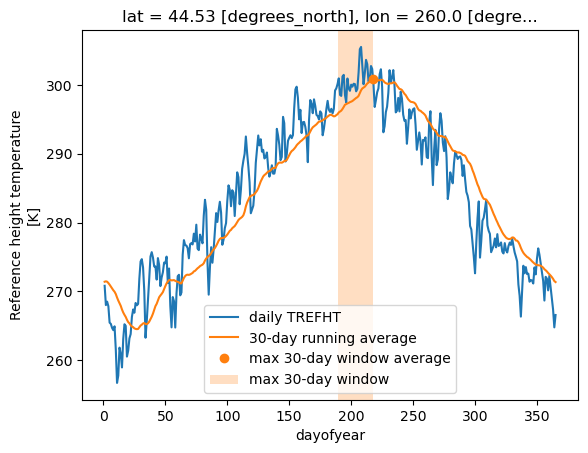

In [78]:
gc = dict(lat=45, lon=260, method="nearest")

x.sel(**gc).plot(label="daily TREFHT")

idx = end_iday.sel(**gc)
trailing_mean.sel(**gc).plot(label=f"{ndays}-day running average")
plt.plot(
    trailing_mean.dayofyear[idx],
    trailing_mean.sel(**gc)[idx],
    marker="o", alpha=1, lw=0,
    color='tab:orange',
    label=f"max {ndays}-day window average"
)
plt.axvspan(
    window.sel(**gc, window_day=0),
    window.sel(**gc, window_day=29),
    facecolor='tab:orange',
    alpha=0.25,
    label=f"max {ndays}-day window"
)

plt.legend()

In [84]:
def select_window(other: xr.DataArray, doy_labels: xr.DataArray) -> xr.DataArray:
    """
    Select time steps of `other` whose day-of-year falls within the
    per-gridpoint window defined by `doy_labels`.

    Parameters
    ----------
    other : xr.DataArray
        Array with a 'time' dimension (plus dims matching doy_labels,
        e.g. lat, lon, member).
    doy_labels : xr.DataArray
        Output of max_window_doy: 1-indexed dayofyear labels, dims
        (*non-time dims, 'window_day').

    Returns
    -------
    xr.DataArray
        `other` masked (NaN outside the window) with the same dims as
        `other`, plus a boolean 'in_window' mask attached for
        transparency if you'd rather use .where() yourself downstream.
    """
    time_doy = other["time"].dt.dayofyear  # dims: (time,)

    # Broadcast comparison: (time,) vs (*, window_day) -> (time, *, window_day)
    mask = (time_doy == doy_labels).any(dim="window_day")  # dims: (time, *doy_labels.dims[:-1])

    return other.where(mask)

In [ ]:
time_doy = y.time.dt.dayofyear

<xarray.DataArray 'dayofyear' (time: 730)> Size: 6kB
array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
       144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
       157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
       170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182,
       183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195,
       196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208,
       209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221,
       222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234,
       235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246, 247,
       248, 249, 250, 251, 252, 253, 254, 255, 256, 257, 258, 259, 260,
...
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181,
       182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194,
       195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207,
       208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220,
       221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233,
       234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246,
       247, 248, 249, 250, 251, 252, 253, 254, 255, 256, 257, 258, 259,
       260, 261, 262, 263, 264, 265, 266, 267, 268, 269, 270, 271, 272,
       273, 274, 275, 276, 277, 278, 279, 280, 281, 282, 283, 284, 285,
       286, 287, 288, 289, 290, 291, 292, 293, 294, 295, 296, 297, 298,
       299, 300, 301, 302, 303, 304, 305, 306, 307, 308, 309, 310, 311,
       312, 313, 314, 315, 316, 317, 318, 319, 320, 321, 322, 323, 324,
       325, 326, 327, 328, 329, 330, 331, 332, 333, 334, 335, 336, 337,
       338, 339, 340, 341, 342, 343, 344, 345, 346, 347, 348, 349, 350,
       351, 352, 353, 354, 355, 356, 357, 358, 359, 360, 361, 362, 363,
       364, 365])
Coordinates:
  * time     (time) object 6kB 1950-01-01 00:00:00 ... 1951-12-31 00:00:00
    member   int64 8B 0
Attributes:
    long_name:  time
    bounds:     time_bnds

In [86]:
select_window(y, window)

<xarray.DataArray 'TREFHT' (time: 730, lat: 96, lon: 144)> Size: 40MB
dask.array<where, shape=(730, 96, 144), dtype=float32, chunksize=(1, 96, 144), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 6kB 1950-01-01 00:00:00 ... 1951-12-31 00:00:00
  * lat      (lat) float64 768B -90.0 -88.11 -86.21 -84.32 ... 86.21 88.11 90.0
  * lon      (lon) float64 1kB 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
    member   int64 8B 0
Attributes:
    units:         K
    long_name:     Reference height temperature
    cell_methods:  time: mean